# 02. Statistical Foundations of Anomaly Detection

The first notebook framed anomaly detection as a decision system. This notebook builds the statistical foundation underneath that frame. Before using isolation forests, one-class SVMs, autoencoders, or sequence models, we need to understand what it means for a case to be statistically unusual.

The main objects in this lecture are tail probabilities, robust location and scale, empirical quantiles, covariance, Mahalanobis distance, and calibrated alert rates. These ideas are simple enough to compute by hand in small examples, but they remain central in production anomaly detection.

The decision-science theme is this: a statistical threshold still needs operational translation. A good anomaly detector must control false alerts, recognize heavy tails, respect correlation structure, and remain stable when the data contain the very outliers it is trying to find.

## Learning Objectives

By the end of this lecture, you should be able to:

1. Explain anomaly detection using tail probabilities and null baselines.
2. Compute expected false alerts and family-wise false alert probability across many monitored units.
3. Compare classical z-scores with robust median/MAD scores.
4. Explain why heavy-tailed data break naive three-sigma thinking.
5. Use empirical quantiles as distribution-light thresholds.
6. Define Mahalanobis distance and connect it to covariance geometry.
7. Explain why outliers can contaminate classical covariance estimates.
8. Compare classical and robust multivariate anomaly scores.
9. Translate statistical thresholds into decision-system language.

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import chi2, norm, t
from sklearn.covariance import EmpiricalCovariance, MinCovDet
from sklearn.metrics import average_precision_score, roc_auc_score

repo_root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'notebooks' / '_shared' / 'display.py').exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from notebooks._shared.display import smart_display

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 130
pd.set_option('display.max_colwidth', 160)

RANDOM_SEED = 2027

## 1. The Baseline Model and Tail Probability View

At the most basic level, anomaly detection asks whether an observation is surprising under a baseline model. Let $X$ denote a monitored measurement and let $P_0$ denote the distribution of normal behavior. A tail-probability detector alerts when

$$
P_0(S(X) \ge S(x_i)) \le \alpha,
$$

where $S(x)$ is a score that increases with unusualness and $\alpha$ is the tolerated tail probability.

For a standard normal measurement, the familiar z-score is

$$
Z_i = \frac{x_i - \mu}{\sigma}.
$$

A two-sided point anomaly rule alerts when

$$
2\{1 - \Phi(|Z_i|)\} \le \alpha,
$$

or equivalently when $|Z_i|$ exceeds a critical value.

This makes the interpretation of the threshold explicit: it is a statement about how often normal data should cross the line.

### False Alerts Accumulate Across Many Monitored Units

If one normal observation has false alert probability $\alpha$, then monitoring $n$ independent normal observations has expected false alerts

$$
\mathbb{E}[V] = n\alpha.
$$

The probability of at least one false alert is

$$
\Pr(V \ge 1) = 1 - (1 - \alpha)^n.
$$

This is one reason anomaly detection feels noisy in production. A threshold that seems conservative for one point can create many alerts when applied across thousands of transactions, machines, accounts, or time windows.

In [2]:
alpha_grid = [0.10, 0.05, 0.01, 0.001]
n_grid = [100, 1_000, 10_000, 100_000]

false_alert_rows = []
for n in n_grid:
    for alpha in alpha_grid:
        false_alert_rows.append({
            'monitored_units': n,
            'per_unit_alpha': alpha,
            'expected_false_alerts': n * alpha,
            'probability_at_least_one_false_alert': 1 - (1 - alpha) ** n,
            'two_sided_normal_z_cutoff': norm.ppf(1 - alpha / 2),
        })
false_alert_table = pd.DataFrame(false_alert_rows)

display_table = false_alert_table.copy()
display_table['per_unit_alpha'] = display_table['per_unit_alpha'].map(lambda value: f'{value:.3f}')
display_table['expected_false_alerts'] = display_table['expected_false_alerts'].map(lambda value: f'{value:,.1f}')
display_table['probability_at_least_one_false_alert'] = display_table['probability_at_least_one_false_alert'].map(lambda value: f'{value:.1%}')
display_table['two_sided_normal_z_cutoff'] = display_table['two_sided_normal_z_cutoff'].map(lambda value: f'{value:.2f}')
smart_display(display_table, max_width='760px')

,monitored_units,per_unit_alpha,expected_false_alerts,probability_at_least_one_false_alert,two_sided_normal_z_cutoff
0,100,0.100,10.0,100.0%,1.64
1,100,0.050,5.0,99.4%,1.96
2,100,0.010,1.0,63.4%,2.58
3,100,0.001,0.1,9.5%,3.29
4,1000,0.100,100.0,100.0%,1.64
5,1000,0.050,50.0,100.0%,1.96
6,1000,0.010,10.0,100.0%,2.58
7,1000,0.001,1.0,63.2%,3.29
8,10000,0.100,"1,000.0",100.0%,1.64
9,10000,0.050,500.0,100.0%,1.96


For False Alerts Accumulate Across Many Monitored Units, separate unusual behavior from useful triage. The alert is valuable only when it changes the next review step.


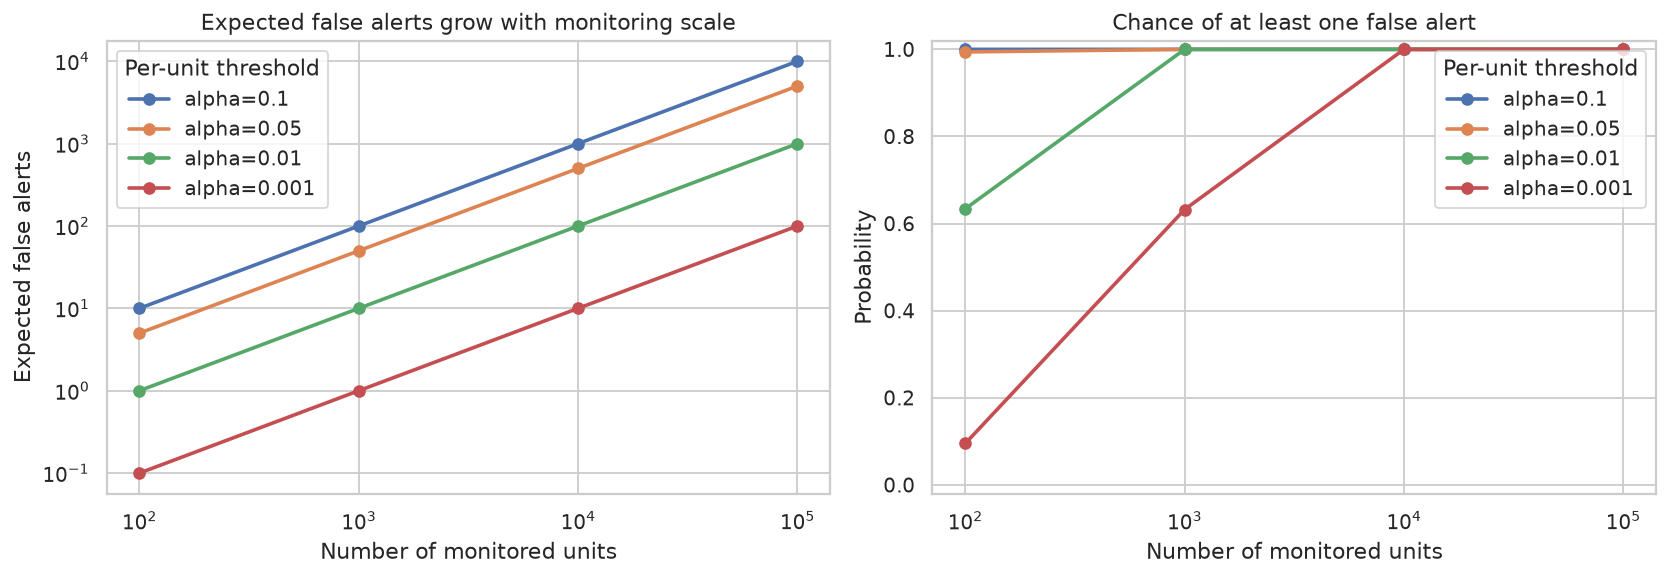

In [3]:
# Section focus: False Alerts Accumulate Across Many Monitored Units.
# The code below keeps the calculation explicit so each intermediate step can be inspected.

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.6))

plot_table = false_alert_table.copy()
for alpha in alpha_grid:
    subset = plot_table.loc[plot_table['per_unit_alpha'] == alpha]
    axes[0].plot(subset['monitored_units'], subset['expected_false_alerts'], marker='o', linewidth=2.0, label=f'alpha={alpha:g}')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_title('Expected false alerts grow with monitoring scale')
axes[0].set_xlabel('Number of monitored units')
axes[0].set_ylabel('Expected false alerts')
axes[0].legend(title='Per-unit threshold')

for alpha in alpha_grid:
    subset = plot_table.loc[plot_table['per_unit_alpha'] == alpha]
    axes[1].plot(subset['monitored_units'], subset['probability_at_least_one_false_alert'], marker='o', linewidth=2.0, label=f'alpha={alpha:g}')
axes[1].set_xscale('log')
axes[1].set_ylim(-0.02, 1.02)
axes[1].set_title('Chance of at least one false alert')
axes[1].set_xlabel('Number of monitored units')
axes[1].set_ylabel('Probability')
axes[1].legend(title='Per-unit threshold')

plt.tight_layout()
plt.show()

The table shows why anomaly detection concerns the whole alert workload, not a single point crossing a cutoff. At a per-unit false alert probability of $\alpha = 0.01$, monitoring 10,000 normal units produces about 100 expected false alerts. This may be acceptable for automated logging, but not for a human review queue.

A production threshold therefore needs two interpretations:

- **statistical interpretation:** how rare is the event under the baseline?
- **operational interpretation:** how many cases will this send to review?

## 2. Classical z-Scores and Robust z-Scores

The classical z-score uses the sample mean and standard deviation:

$$
z_i = \frac{x_i - \bar x}{s}.
$$

This works well when the baseline is close to symmetric, light-tailed, and uncontaminated. But anomaly detection data are often contaminated by the anomalies themselves. Extreme values can inflate $s$ and pull $\bar x$, making other outliers look less unusual.

A robust alternative uses the median and median absolute deviation (MAD):

$$
z_i^{\mathrm{robust}} = \frac{x_i - \operatorname{median}(x)}{1.4826 \cdot \operatorname{median}(|x_i - \operatorname{median}(x)|)}.
$$

The constant $1.4826$ rescales MAD to estimate the standard deviation under normality.

In [4]:
# Section focus: 2. Classical z-Scores and Robust z-Scores.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def robust_z(values):
    """Carry out the robust z step used in the 02. Statistical Foundations of Anomaly Detection workflow.
    
    Parameters
    ----------
    values : object
        The values setting that controls the robust z calculation in this notebook.
    
    Returns
    -------
    object
        Intermediate result produced by the robust z calculation and reused by later cells.
    """
    values = np.asarray(values)
    median = np.median(values)
    mad = np.median(np.abs(values - median))
    scale = 1.4826 * mad if mad > 0 else np.std(values)
    return (values - median) / scale


def simulate_cycle_times(n=3000, seed=RANDOM_SEED):
    """Create a simulated cycle times data set for the 02. Statistical Foundations of Anomaly Detection case study.
    
    Parameters
    ----------
    n : object
        Number of observations or simulation units used by the calculation.
    seed : object
        Random seed used to make the simulation reproducible.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rng = np.random.default_rng(seed)
    baseline = rng.lognormal(mean=np.log(18), sigma=0.18, size=n)
    anomaly = rng.random(n) < 0.035
    baseline[anomaly] *= rng.uniform(2.3, 4.8, anomaly.sum())
    return pd.DataFrame({'cycle_minutes': baseline, 'known_anomaly': anomaly.astype(int)})

cycle_df = simulate_cycle_times()
cycle_df['classical_z'] = (cycle_df['cycle_minutes'] - cycle_df['cycle_minutes'].mean()) / cycle_df['cycle_minutes'].std(ddof=1)
cycle_df['robust_z'] = robust_z(cycle_df['cycle_minutes'])
cycle_df['abs_classical_z'] = cycle_df['classical_z'].abs()
cycle_df['abs_robust_z'] = cycle_df['robust_z'].abs()

cycle_summary = pd.DataFrame({
    'Quantity': [
        'Mean cycle time',
        'Median cycle time',
        'Standard deviation',
        'MAD-scaled robust spread',
        'Known anomaly rate',
        'Classical z alerts at |z| > 3',
        'Robust z alerts at |z| > 3',
    ],
    'Value': [
        cycle_df['cycle_minutes'].mean(),
        cycle_df['cycle_minutes'].median(),
        cycle_df['cycle_minutes'].std(ddof=1),
        1.4826 * np.median(np.abs(cycle_df['cycle_minutes'] - cycle_df['cycle_minutes'].median())),
        cycle_df['known_anomaly'].mean(),
        (cycle_df['abs_classical_z'] > 3).mean(),
        (cycle_df['abs_robust_z'] > 3).mean(),
    ],
})
cycle_summary_display = cycle_summary.copy()
cycle_summary_display['Value'] = cycle_summary_display['Value'].map(lambda value: f'{value:.3f}')
smart_display(cycle_summary_display, max_width='620px')

,Quantity,Value
0,Mean cycle time,19.699
1,Median cycle time,18.152
2,Standard deviation,8.930
3,MAD-scaled robust spread,3.408
4,Known anomaly rate,0.032
5,Classical z alerts at |z| > 3,0.026
6,Robust z alerts at |z| > 3,0.036


Classical z-Scores and Robust z-Scores is less about the score itself and more about whether the score creates an actionable investigation path.


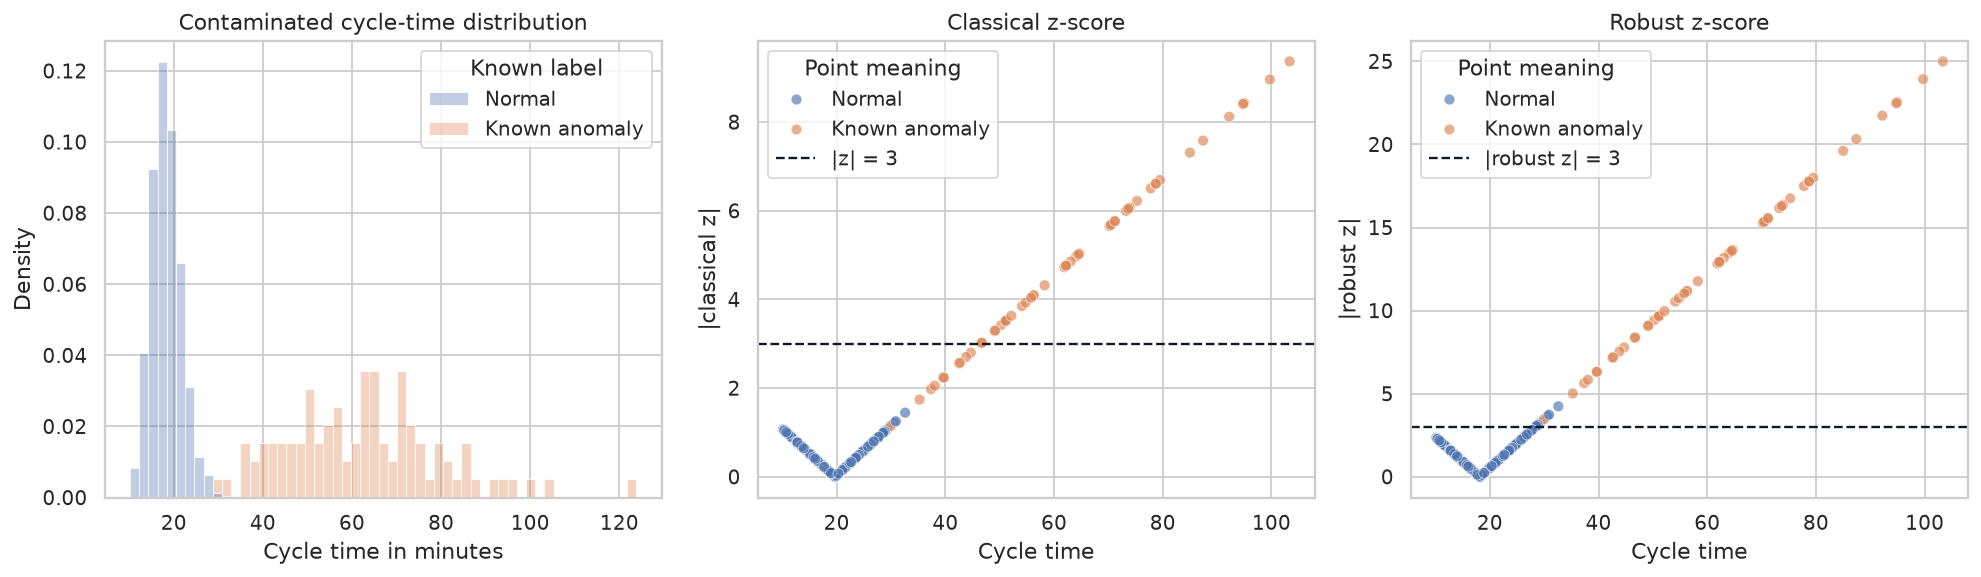

In [5]:
# Section focus: 2. Classical z-Scores and Robust z-Scores.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

fig, axes = plt.subplots(1, 3, figsize=(15.4, 4.6))

cycle_plot = cycle_df.copy()
cycle_plot['Known label'] = np.where(cycle_plot['known_anomaly'] == 1, 'Known anomaly', 'Normal')
palette = {'Normal': '#4c72b0', 'Known anomaly': '#dd8452'}

sns.histplot(
    cycle_plot,
    x='cycle_minutes',
    hue='Known label',
    hue_order=['Normal', 'Known anomaly'],
    palette=palette,
    bins=55,
    stat='density',
    common_norm=False,
    alpha=0.35,
    ax=axes[0],
)
axes[0].set_title('Contaminated cycle-time distribution')
axes[0].set_xlabel('Cycle time in minutes')
axes[0].set_ylabel('Density')

scatter_sample = cycle_plot.sample(1500, random_state=RANDOM_SEED)
sns.scatterplot(
    data=scatter_sample,
    x='cycle_minutes',
    y='abs_classical_z',
    hue='Known label',
    hue_order=['Normal', 'Known anomaly'],
    palette=palette,
    alpha=0.65,
    ax=axes[1],
)
axes[1].axhline(3, color='#111827', linestyle='--', linewidth=1.3, label='|z| = 3')
axes[1].set_title('Classical z-score')
axes[1].set_xlabel('Cycle time')
axes[1].set_ylabel('|classical z|')
axes[1].legend(title='Point meaning')

sns.scatterplot(
    data=scatter_sample,
    x='cycle_minutes',
    y='abs_robust_z',
    hue='Known label',
    hue_order=['Normal', 'Known anomaly'],
    palette=palette,
    alpha=0.65,
    ax=axes[2],
)
axes[2].axhline(3, color='#111827', linestyle='--', linewidth=1.3, label='|robust z| = 3')
axes[2].set_title('Robust z-score')
axes[2].set_xlabel('Cycle time')
axes[2].set_ylabel('|robust z|')
axes[2].legend(title='Point meaning')

plt.tight_layout()
plt.show()

Read Classical z-Scores and Robust z-Scores with the reviewer in mind. A useful detector narrows the review queue rather than widening it.


In [6]:
score_comparison = pd.DataFrame({
    'score': ['Classical |z|', 'Robust |z|'],
    'roc_auc': [
        roc_auc_score(cycle_df['known_anomaly'], cycle_df['abs_classical_z']),
        roc_auc_score(cycle_df['known_anomaly'], cycle_df['abs_robust_z']),
    ],
    'average_precision': [
        average_precision_score(cycle_df['known_anomaly'], cycle_df['abs_classical_z']),
        average_precision_score(cycle_df['known_anomaly'], cycle_df['abs_robust_z']),
    ],
    'precision_at_three_sigma': [
        cycle_df.loc[cycle_df['abs_classical_z'] > 3, 'known_anomaly'].mean(),
        cycle_df.loc[cycle_df['abs_robust_z'] > 3, 'known_anomaly'].mean(),
    ],
    'recall_at_three_sigma': [
        cycle_df.loc[cycle_df['known_anomaly'] == 1, 'abs_classical_z'].gt(3).mean(),
        cycle_df.loc[cycle_df['known_anomaly'] == 1, 'abs_robust_z'].gt(3).mean(),
    ],
})
smart_display(score_comparison.round(3), max_width='760px')

,score,roc_auc,average_precision,precision_at_three_sigma,recall_at_three_sigma
0,Classical |z|,1.0,0.999,1.00,0.832
1,Robust |z|,1.0,0.999,0.88,1.000


Both scores rank large cycle times as unusual, but they differ in threshold behavior. The classical standard deviation is inflated by extreme cases, which can make a fixed threshold such as $|z|>3$ less sensitive. The robust score uses a baseline built from the center of the distribution, so it is less distorted by the same anomalous cases.

Robust z-scores are a baseline tool. Their main lesson is conceptual: the baseline estimator matters.

## 3. Heavy Tails and the Limits of Three-Sigma Rules

A three-sigma rule is often interpreted as very conservative because, for a normal variable,

$$
\Pr(|Z| > 3) \approx 0.0027.
$$

But real operational measurements are frequently skewed or heavy-tailed. If the baseline has heavier tails than a normal distribution, the same three-sigma threshold can create many more alerts.

Let $T_\nu$ be a Student-$t$ variable with $\nu$ degrees of freedom, standardized to unit variance. Its tail probability can be much larger than the normal tail probability even when the center of the distribution looks similar.

In [7]:
tail_grid = np.linspace(1.0, 5.0, 81)
tail_table = pd.DataFrame({
    'cutoff': tail_grid,
    'normal_two_sided_tail': 2 * (1 - norm.cdf(tail_grid)),
    't_df3_two_sided_tail': 2 * (1 - t.cdf(tail_grid, df=3)),
    't_df5_two_sided_tail': 2 * (1 - t.cdf(tail_grid, df=5)),
})

three_sigma_summary = pd.DataFrame({
    'baseline': ['Normal', 'Student-t df=5', 'Student-t df=3'],
    'two_sided_tail_at_3': [
        2 * (1 - norm.cdf(3)),
        2 * (1 - t.cdf(3, df=5)),
        2 * (1 - t.cdf(3, df=3)),
    ],
})
three_sigma_summary['expected_alerts_per_10000'] = 10_000 * three_sigma_summary['two_sided_tail_at_3']
three_sigma_display = three_sigma_summary.copy()
three_sigma_display['two_sided_tail_at_3'] = three_sigma_display['two_sided_tail_at_3'].map(lambda value: f'{value:.3%}')
three_sigma_display['expected_alerts_per_10000'] = three_sigma_display['expected_alerts_per_10000'].map(lambda value: f'{value:,.1f}')
smart_display(three_sigma_display, max_width='620px')

,baseline,two_sided_tail_at_3,expected_alerts_per_10000
0,Normal,0.270%,27.0
1,Student-t df=5,3.010%,301.0
2,Student-t df=3,5.767%,576.7


In Heavy Tails and the Limits of Three-Sigma Rules, the useful signal is the part that survives contact with seasonality, measurement noise, and routine variation.


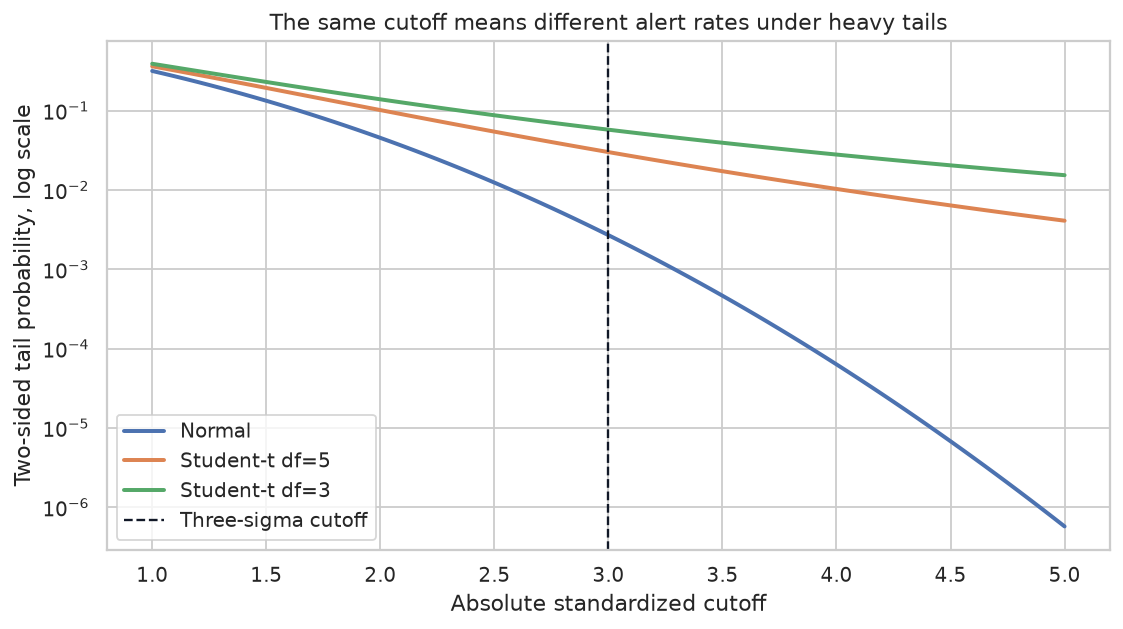

In [8]:
fig, ax = plt.subplots(figsize=(8.8, 5.0))
ax.plot(tail_table['cutoff'], tail_table['normal_two_sided_tail'], label='Normal', linewidth=2.2)
ax.plot(tail_table['cutoff'], tail_table['t_df5_two_sided_tail'], label='Student-t df=5', linewidth=2.2)
ax.plot(tail_table['cutoff'], tail_table['t_df3_two_sided_tail'], label='Student-t df=3', linewidth=2.2)
ax.axvline(3, color='#111827', linestyle='--', linewidth=1.3, label='Three-sigma cutoff')
ax.set_yscale('log')
ax.set_title('The same cutoff means different alert rates under heavy tails')
ax.set_xlabel('Absolute standardized cutoff')
ax.set_ylabel('Two-sided tail probability, log scale')
ax.legend()
plt.tight_layout()
plt.show()

The three-sigma threshold has a precise meaning only after the baseline distribution is specified. Under heavier tails, values beyond three standardized units may be normal operating variation rather than actionable incidents.

This is why many production systems prefer empirical quantiles, segment-specific thresholds, or explicitly calibrated thresholds over inherited textbook rules.

## 4. Empirical Quantiles as Operational Thresholds

A distribution-light alternative is to choose a threshold by an empirical quantile. If $S$ is an anomaly score and the team can review approximately the top $q$ fraction of cases, then one policy is

$$
t_q = \widehat{Q}_{1-q}(S), \qquad d_i = \mathbf{1}\{S_i \ge t_q\}.
$$

This does not require a normality assumption. It directly controls review volume in the historical sample. But it has its own risks: if the historical sample is contaminated, shifted, or not representative of deployment, the threshold may be poorly calibrated.

In [9]:
quantile_policies = []
for review_rate in [0.01, 0.02, 0.05, 0.10]:
    threshold = cycle_df['abs_robust_z'].quantile(1 - review_rate)
    alert = cycle_df['abs_robust_z'] >= threshold
    quantile_policies.append({
        'target_review_rate': review_rate,
        'threshold': threshold,
        'actual_review_rate': alert.mean(),
        'precision': cycle_df.loc[alert, 'known_anomaly'].mean(),
        'recall': cycle_df.loc[cycle_df['known_anomaly'] == 1, 'abs_robust_z'].ge(threshold).mean(),
    })
quantile_policy_table = pd.DataFrame(quantile_policies)
quantile_policy_display = quantile_policy_table.copy()
for column in ['target_review_rate', 'actual_review_rate', 'precision', 'recall']:
    quantile_policy_display[column] = quantile_policy_display[column].map(lambda value: f'{value:.1%}')
quantile_policy_display['threshold'] = quantile_policy_display['threshold'].map(lambda value: f'{value:.2f}')
smart_display(quantile_policy_display, max_width='760px')

,target_review_rate,threshold,actual_review_rate,precision,recall
0,1.0%,15.27,1.0%,100.0%,31.6%
1,2.0%,10.83,2.0%,100.0%,63.2%
2,5.0%,2.38,5.0%,63.3%,100.0%
3,10.0%,1.74,10.0%,31.7%,100.0%


For Empirical Quantiles as Operational Thresholds, focus on what the alert would make an analyst do next: investigate, suppress, monitor, or revise the rule.


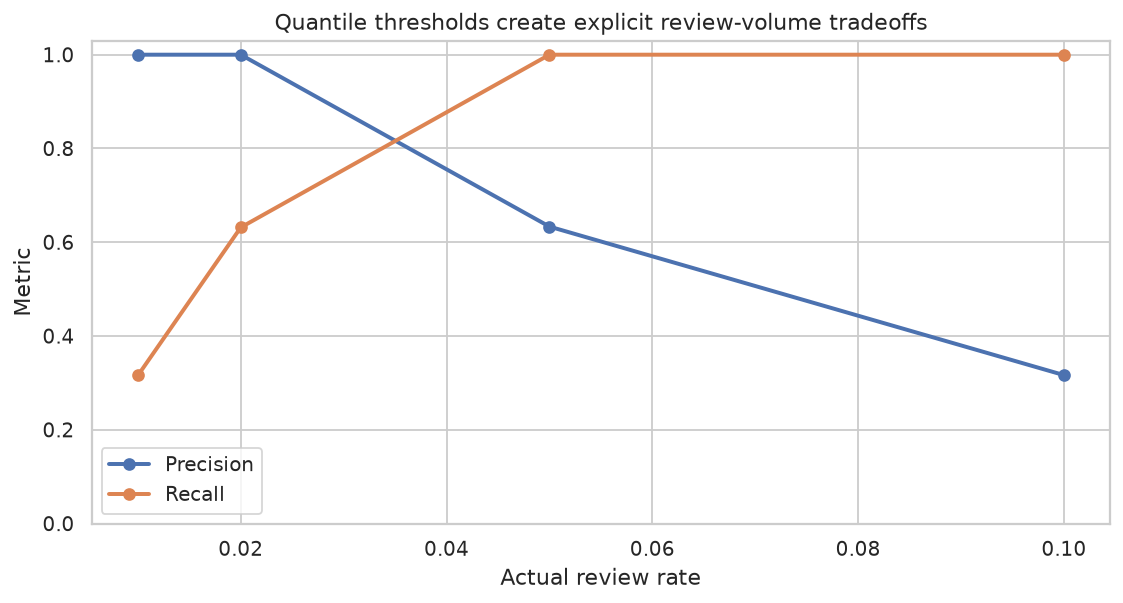

In [10]:
fig, ax = plt.subplots(figsize=(8.8, 4.8))
review_rates = quantile_policy_table['actual_review_rate']
ax.plot(review_rates, quantile_policy_table['precision'], marker='o', linewidth=2.2, label='Precision')
ax.plot(review_rates, quantile_policy_table['recall'], marker='o', linewidth=2.2, label='Recall')
ax.set_title('Quantile thresholds create explicit review-volume tradeoffs')
ax.set_xlabel('Actual review rate')
ax.set_ylabel('Metric')
ax.set_ylim(0, 1.03)
ax.legend()
plt.tight_layout()
plt.show()

Quantile thresholds make the staffing constraint explicit. A top-1% rule is much more selective than a top-10% rule, but it catches fewer true anomalies. This is the same decision tension as notebook 01, now expressed using empirical score quantiles.

A useful practice is to report both the threshold and the implied historical review load. Thresholds without alert-volume estimates are hard to govern.

## 5. Multivariate Anomalies and Mahalanobis Distance

Univariate rules miss cases that are not extreme in any one feature but are unusual as a combination. Suppose $X \in \mathbb{R}^p$ has normal baseline mean $\mu$ and covariance matrix $\Sigma$. The squared Mahalanobis distance is

$$
D_i^2 = (x_i - \mu)^\top \Sigma^{-1}(x_i - \mu).
$$

This distance accounts for scale and correlation. If the normal baseline is multivariate normal, then approximately

$$
D_i^2 \sim \chi^2_p.
$$

An alert threshold can therefore be based on a chi-square quantile:

$$
D_i^2 > \chi^2_{p, 1-\alpha}.
$$

The important idea is geometric: normal data occupy an ellipsoid, not a rectangle. Mahalanobis distance measures how far a point lies from the center after accounting for the ellipsoid's shape.

In [11]:
def simulate_multivariate_operations(n=4200, seed=RANDOM_SEED):
    """Create a simulated multivariate operations data set for the 02. Statistical Foundations of Anomaly Detection case study.
    
    Parameters
    ----------
    n : object
        Number of observations or simulation units used by the calculation.
    seed : object
        Random seed used to make the simulation reproducible.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rng = np.random.default_rng(seed)
    mean = np.array([0.0, 0.0])
    cov = np.array([[1.0, 0.78], [0.78, 1.0]])
    normal = rng.multivariate_normal(mean, cov, size=n)
    labels = np.zeros(n, dtype=int)
    anomaly_type = np.array(['normal'] * n, dtype=object)

    # Relationship anomalies: not extreme on each axis, but inconsistent with the normal positive correlation.
    relationship_count = int(0.035 * n)
    idx_rel = rng.choice(n, size=relationship_count, replace=False)
    normal[idx_rel, 0] = rng.normal(1.5, 0.32, relationship_count)
    normal[idx_rel, 1] = rng.normal(-1.4, 0.32, relationship_count)
    labels[idx_rel] = 1
    anomaly_type[idx_rel] = 'correlation_break'

    # Tail anomalies: extreme in both dimensions.
    remaining = np.setdiff1d(np.arange(n), idx_rel)
    tail_count = int(0.020 * n)
    idx_tail = rng.choice(remaining, size=tail_count, replace=False)
    normal[idx_tail] += rng.normal([3.0, 2.8], [0.35, 0.35], size=(tail_count, 2))
    labels[idx_tail] = 1
    anomaly_type[idx_tail] = 'joint_tail'

    return pd.DataFrame({
        'standardized_queue_pressure': normal[:, 0],
        'standardized_cycle_time': normal[:, 1],
        'known_anomaly': labels,
        'anomaly_type': anomaly_type,
    })

multi_df = simulate_multivariate_operations()
feature_matrix = multi_df[['standardized_queue_pressure', 'standardized_cycle_time']].to_numpy()

emp_cov = EmpiricalCovariance().fit(feature_matrix)
robust_cov = MinCovDet(random_state=RANDOM_SEED, support_fraction=0.80).fit(feature_matrix)

multi_df['classical_mahalanobis_d2'] = emp_cov.mahalanobis(feature_matrix)
multi_df['robust_mahalanobis_d2'] = robust_cov.mahalanobis(feature_matrix)

alpha = 0.01
chi_square_cutoff = chi2.ppf(1 - alpha, df=2)
multi_df['classical_alert'] = multi_df['classical_mahalanobis_d2'] > chi_square_cutoff
multi_df['robust_alert'] = multi_df['robust_mahalanobis_d2'] > chi_square_cutoff

mahalanobis_metrics = pd.DataFrame({
    'score': ['Classical Mahalanobis $D^2$', 'Robust Mahalanobis $D^2$'],
    'roc_auc': [
        roc_auc_score(multi_df['known_anomaly'], multi_df['classical_mahalanobis_d2']),
        roc_auc_score(multi_df['known_anomaly'], multi_df['robust_mahalanobis_d2']),
    ],
    'average_precision': [
        average_precision_score(multi_df['known_anomaly'], multi_df['classical_mahalanobis_d2']),
        average_precision_score(multi_df['known_anomaly'], multi_df['robust_mahalanobis_d2']),
    ],
    'alert_rate_at_chi_square_99pct': [multi_df['classical_alert'].mean(), multi_df['robust_alert'].mean()],
    'precision_at_chi_square_99pct': [
        multi_df.loc[multi_df['classical_alert'], 'known_anomaly'].mean(),
        multi_df.loc[multi_df['robust_alert'], 'known_anomaly'].mean(),
    ],
    'recall_at_chi_square_99pct': [
        multi_df.loc[multi_df['known_anomaly'] == 1, 'classical_alert'].mean(),
        multi_df.loc[multi_df['known_anomaly'] == 1, 'robust_alert'].mean(),
    ],
})
mahalanobis_display = mahalanobis_metrics.copy()
for column in ['roc_auc', 'average_precision']:
    mahalanobis_display[column] = mahalanobis_display[column].map(lambda value: f'{value:.3f}')
for column in ['alert_rate_at_chi_square_99pct', 'precision_at_chi_square_99pct', 'recall_at_chi_square_99pct']:
    mahalanobis_display[column] = mahalanobis_display[column].map(lambda value: f'{value:.1%}')
smart_display(mahalanobis_display, max_width='920px')

,score,roc_auc,average_precision,alert_rate_at_chi_square_99pct,precision_at_chi_square_99pct,recall_at_chi_square_99pct
0,Classical Mahalanobis $D^2$,0.984,0.884,3.6%,95.4%,62.3%
1,Robust Mahalanobis $D^2$,0.986,0.917,5.4%,86.7%,84.4%


Multivariate Anomalies and Mahalanobis Distance should be read as an operations question. The practical test is whether the score points to something worth reviewing.


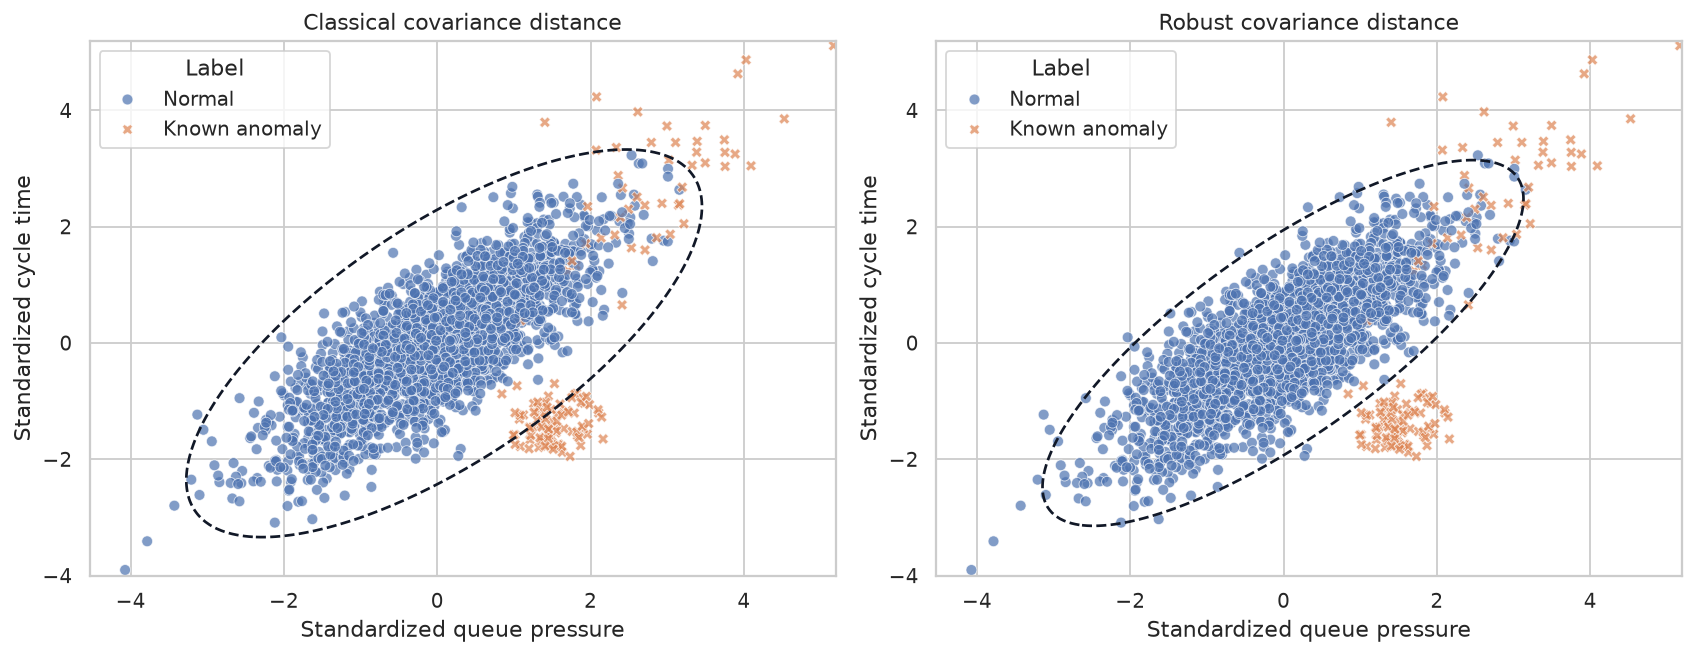

In [12]:
# Section focus: 5. Multivariate Anomalies and Mahalanobis Distance.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.2))

plot_sample = multi_df.sample(2500, random_state=RANDOM_SEED).copy()
plot_sample['Known label'] = np.where(plot_sample['known_anomaly'] == 1, 'Known anomaly', 'Normal')

for ax, score_col, title in [
    (axes[0], 'classical_mahalanobis_d2', 'Classical covariance distance'),
    (axes[1], 'robust_mahalanobis_d2', 'Robust covariance distance'),
]:
    sns.scatterplot(
        data=plot_sample,
        x='standardized_queue_pressure',
        y='standardized_cycle_time',
        hue='Known label',
        style='Known label',
        alpha=0.70,
        ax=ax,
    )
    # Draw approximate alert contours by evaluating the score over a grid.
    xx, yy = np.meshgrid(np.linspace(-4.0, 5.2, 180), np.linspace(-4.0, 5.2, 180))
    grid = np.c_[xx.ravel(), yy.ravel()]
    cov_model = emp_cov if score_col == 'classical_mahalanobis_d2' else robust_cov
    zz = cov_model.mahalanobis(grid).reshape(xx.shape)
    ax.contour(xx, yy, zz, levels=[chi_square_cutoff], colors='#111827', linestyles='--', linewidths=1.5)
    ax.set_title(title)
    ax.set_xlabel('Standardized queue pressure')
    ax.set_ylabel('Standardized cycle time')
    ax.legend(title='Label')

plt.tight_layout()
plt.show()

The multivariate example shows the value of covariance-aware scoring. Some anomalies violate the normal relationship between queue pressure and cycle time. They may not be the largest values on either feature individually, but they are unusual relative to the joint pattern.

The robust covariance version is less influenced by contaminated points when estimating the normal ellipsoid. This connects to the robust covariance literature: robust location and scatter estimators are designed to reduce masking and swamping effects when outliers distort classical estimates (Cabana et al., 2019; Hubert et al., 2017).

## 6. Statistical Scorecards for Decision Systems

A statistical anomaly detector should be reported with a useful scorecard as well as a model object. A useful scorecard contains:

| Component | What to report | Why it matters |
|---|---|---|
| Baseline | Distribution, segment, time window, or peer group | Defines what normal means |
| Score | Formula and direction | Makes unusualness auditable |
| Threshold | Tail probability, quantile, or decision cutoff | Converts score into action |
| Expected load | Alerts per day, week, or batch | Connects statistics to staffing |
| Error profile | Precision, recall, false alert rate, missed cases | Connects statistics to risk |
| Stability check | Sensitivity to contamination, drift, and heavy tails | Prevents brittle monitoring |

This is the foundation for the next notebooks. We will soon move from simple statistical detectors to distance, density, tree, one-class, reconstruction, and time-series methods. But the same scorecard still applies.

In [13]:
scorecard = pd.DataFrame({
    'Question': [
        'What is the baseline?',
        'What is the score?',
        'How is the threshold chosen?',
        'What review load follows?',
        'How sensitive is the baseline?',
        'What should operators do?',
    ],
    'Good statistical answer': [
        'Normal behavior is estimated from a recent uncontaminated training window or a justified peer group.',
        'The score increases with tail probability, robust deviation, distance, density rarity, or reconstruction error.',
        'The threshold is tied to a false-alert target, empirical quantile, capacity limit, or utility calculation.',
        'The detector reports expected alerts per operational period, not only a mathematical cutoff.',
        'The detector is checked under contamination, heavy tails, and subgroup-specific baselines.',
        'The alert record explains whether to review, suppress, escalate, or collect more evidence.',
    ],
})
smart_display(scorecard, max_width='780px')

,Question,Good statistical answer
0,What is the baseline?,Normal behavior is estimated from a recent uncontaminated training window or a justified peer group.
1,What is the score?,"The score increases with tail probability, robust deviation, distance, density rarity, or reconstruction error."
2,How is the threshold chosen?,"The threshold is tied to a false-alert target, empirical quantile, capacity limit, or utility calculation."
3,What review load follows?,"The detector reports expected alerts per operational period, not only a mathematical cutoff."
4,How sensitive is the baseline?,"The detector is checked under contamination, heavy tails, and subgroup-specific baselines."
5,What should operators do?,"The alert record explains whether to review, suppress, escalate, or collect more evidence."


In Statistical Scorecards for Decision Systems, the detector earns its keep only if the output sharpens the review queue.


## Key Takeaways

- Tail probabilities are meaningful only relative to a specified baseline distribution.
- Per-unit false alert rates accumulate quickly when monitoring many units.
- Classical z-scores can be distorted by the same outliers they are supposed to detect.
- Median/MAD scores are a simple robust baseline for univariate monitoring.
- Heavy tails make normal-based thresholds overconfident.
- Empirical quantiles directly control historical review volume, but they require representative data.
- Mahalanobis distance detects unusual combinations by accounting for covariance geometry.
- Robust covariance estimates can reduce masking and swamping in multivariate outlier detection.
- Statistical thresholds need operational translation: expected alerts, precision, recall, capacity, and actionability.

## References

Cabana, E., Lillo, R. E., & Laniado, H. (2019). Multivariate outlier detection based on a robust Mahalanobis distance with shrinkage estimators. *Statistical Papers, 62*(4), 1583-1609. [https://doi.org/10.1007/s00362-019-01148-1](https://doi.org/10.1007/s00362-019-01148-1)

Chandola, V., Banerjee, A., & Kumar, V. (2009). Anomaly detection. *ACM Computing Surveys, 41*(3), 1-58. [https://doi.org/10.1145/1541880.1541882](https://doi.org/10.1145/1541880.1541882)

Hodge, V. J., & Austin, J. (2004). A survey of outlier detection methodologies. *Artificial Intelligence Review, 22*(2), 85-126. [https://doi.org/10.1023/B:AIRE.0000045502.10941.a9](https://doi.org/10.1023/B:AIRE.0000045502.10941.a9)

Hubert, M., Debruyne, M., & Rousseeuw, P. J. (2017). Minimum covariance determinant and extensions. *WIREs Computational Statistics, 10*(3), e1421. [https://doi.org/10.1002/wics.1421](https://doi.org/10.1002/wics.1421)

Siffer, A., Fouque, P.-A., Termier, A., & Largouet, C. (2017). Anomaly detection in streams with extreme value theory. *Proceedings of the 23rd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*, 1067-1075. [https://doi.org/10.1145/3097983.3098144](https://doi.org/10.1145/3097983.3098144)
